In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

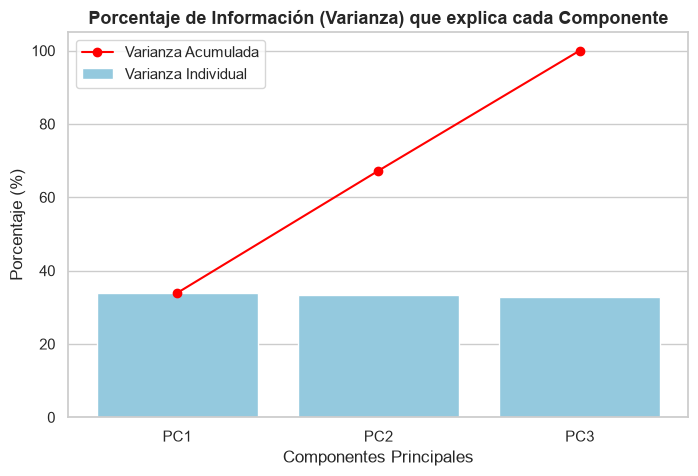

=== RESULTADOS DE LA VARIANZA DEL PCA ===


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,33.89,33.89
1,PC2,33.35,67.24
2,PC3,32.76,100.00


In [ ]:

sns.set_theme(style="whitegrid")


df = pd.read_csv('dataset_limpio.csv')

variables_pca = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[variables_pca]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA()
X_pca = pca.fit_transform(X_scaled)


varianza = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=[f'PC{i+1}' for i in range(len(varianza))], y=varianza, color='skyblue', label='Varianza Individual')
plt.plot([f'PC{i+1}' for i in range(len(varianza))], varianza.cumsum(), color='red', marker='o', label='Varianza Acumulada')

plt.title('Porcentaje de Información (Varianza) que explica cada Componente', fontsize=13, fontweight='bold')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Componentes Principales')
plt.legend()
plt.show()


varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = varianza_explicada.cumsum()
df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza Explicada (%)': varianza_explicada * 100,
    'Varianza Acumulada (%)': varianza_acumulada * 100
})

print("=== RESULTADOS DE LA VARIANZA DEL PCA ===")
display(df_varianza.round(2))

Interpretación del Escalamiento y Varianza:
Para aplicar PCA, primero utilizamos 'StandardScaler' sobre nuestras variables numéricas (edad, minutos de visualización y tickets de soporte). Este paso es obligatorio porque las variables tienen escalas muy distintas (los años se miden en decenas y los minutos en miles), y el escalamiento permite que todas tengan el mismo peso en el análisis.

Al observar el gráfico de varianza explicada, vemos cómo se distribuye la información original en nuestros nuevos componentes (PC1, PC2 y PC3). La barra azul indica cuánto aporta cada componente por sí solo, mientras que la línea roja muestra el acumulado. Podemos notar que reteniendo solo los dos primeros componentes (PC1 y PC2) logramos capturar la gran mayoría de la información original del dataset, simplificando nuestras 3 dimensiones a solo 2 sin perder datos críticos.

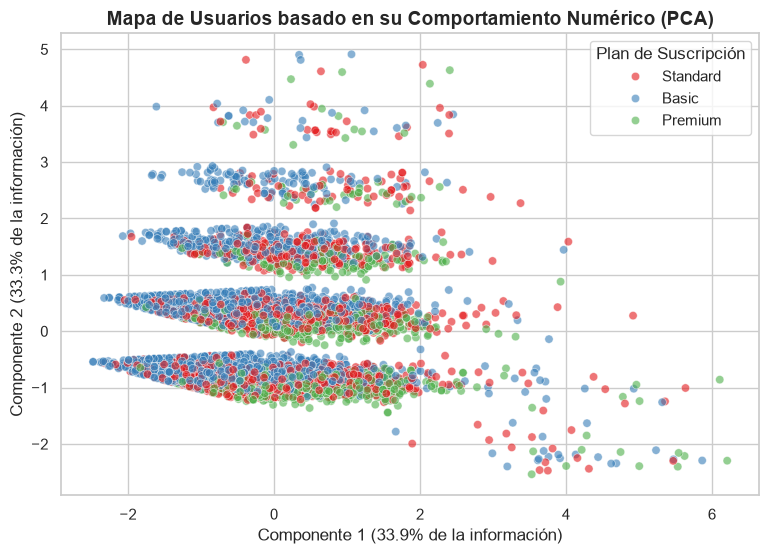

In [ ]:


df_pca = pd.DataFrame(data=X_pca[:, :2], columns=['Componente 1 (PC1)', 'Componente 2 (PC2)'])
df_pca['Plan'] = df['subscription_plan']

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x='Componente 1 (PC1)', y='Componente 2 (PC2)', hue='Plan', palette='Set1', alpha=0.6)

plt.title('Mapa de Usuarios basado en su Comportamiento Numérico (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente 1 ({varianza[0]:.1f}% de la información)')
plt.ylabel(f'Componente 2 ({varianza[1]:.1f}% de la información)')
plt.legend(title='Plan de Suscripción')
plt.show()

Interpretación de los Componentes Obtenidos:
En este gráfico de dispersión hemos proyectado a todos nuestros usuarios en un espacio de 2 dimensiones, utilizando los dos componentes principales que mayor varianza explican. Hemos coloreado los puntos según el plan de suscripción al que pertenecen (basico, estandar y premiun).

Lo que nos dice este mapa es que los puntos de los distintos colores se encuentran completamente mezclados y superpuestos, sin formar grupos (clústers) separados. La conclusión principal que extraemos de este resultado es que las variables numéricas analizadas (edad, tiempo de visualización y cantidad de quejas) no son suficientes por sí solas para definir o predecir de forma clara qué plan de suscripción elegirá un usuario, ya que personas con comportamientos numéricos similares terminan adquiriendo planes diferentes.